# HMM Regime Detection - Modular Analysis

This notebook demonstrates HMM-based market regime detection with:
- Realistic overlapping distributions
- Measurement noise (configurable)
- Proper label identification (Hungarian algorithm)
- Clear separation between model fitting and visualization

## 1. Setup & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.stats import t, skewnorm
from hmmlearn import hmm
from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.style.use("seaborn-v0_8-darkgrid")

# Configuration
DATA_TYPE = "Real"  # Options: "Gaussian", "Broken", "Real"
REAL_DATA_PATH = "hmm_model_input.parquet"
NOISE_LEVEL = 0.15      # 15% measurement noise (realistic for financial data)
N_SAMPLES = 2000
N_REGIMES = 3

REGIME_NAMES = {0: "Bull", 1: "Bear", 2: "Sideways"}
REGIME_COLORS = {"Bull": "#2ecc71", "Bear": "#e74c3c", "Sideways": "#95a5a6"}

print(f"Configuration: {N_SAMPLES} samples, {NOISE_LEVEL:.0%} noise, {N_REGIMES} regimes")
print(f"Data Generation Mode: {DATA_TYPE}")

Configuration: 2000 samples, 15% noise, 3 regimes
Data Generation Mode: Realistic


## 2. Data Generation

Generate synthetic market data with 4 features:
- Log-Returns
- Log-Volatility
- Drawdown
- Yield Curve Slope

In [ ]:
def generate_multifeature_data(n_samples=2000, noise_level=0.0):
    """
    Generate 4D observations with OVERLAPPING distributions (realistic/hard mode).
    """
    model = hmm.GaussianHMM(n_components=3, covariance_type="full")
    
    model.startprob_ = np.array([0.5, 0.2, 0.3])
    
    # Sticky transitions (realistic persistence)
    model.transmat_ = np.array([
        [0.96, 0.01, 0.03],  # Bull persists (~25 days avg)
        [0.02, 0.90, 0.08],  # Bear persists (~10 days avg)
        [0.02, 0.05, 0.93]   # Sideways persists (~14 days avg)
    ])
    
    # OVERLAPPING means (hard mode)
    # [Return, Log-Vol, Drawdown, Yield_Curve]
    model.means_ = np.array([
        [0.0002, -5.0, -0.02, 0.015],   # Bull
        [-0.0002, -4.0, -0.15, -0.005], # Bear (vol close to Bull!)
        [0.0000, -6.0, -0.05, 0.002],   # Sideways
    ])
    
    # Wide covariances (creates overlap)
    cov_bull = np.array([
        [0.00005, 0.0,    0.0,     0.0],
        [0.0,     0.30,   0.0,     0.0],
        [0.0,     0.0,    0.0005,  0.0],
        [0.0,     0.0,    0.0,     0.00001],
    ])
    
    cov_bear = np.array([
        [0.00025, -0.002, -0.0001, 0.00001],
        [-0.002,  0.80,   0.02,    -0.001],
        [-0.0001, 0.02,   0.002,   -0.0001],
        [0.00001, -0.001, -0.0001, 0.00002],
    ])
    
    cov_side = np.array([
        [0.00002, 0.0,    0.0,     0.0],
        [0.0,     0.15,   0.0,     0.0],
        [0.0,     0.0,    0.0003,  0.0],
        [0.0,     0.0,    0.0,     0.00001],
    ])
    
    model.covars_ = np.array([cov_bull, cov_bear, cov_side])
    
    X, Z_true = model.sample(n_samples)
    
    # Add measurement noise
    if noise_level > 0:
        feature_stds = X.std(axis=0)
        noise = np.random.randn(n_samples, 4) * feature_stds * noise_level
        X = X + noise
    
    feature_names = ["Log-Returns", "Log-Volatility", "Drawdown", "Yield Curve"]
    
    return X, Z_true, feature_names

def generate_broken_data(n_samples=2000):
    """
    Generates data that VIOLATES Gaussian assumptions (Fat Tails, Skewness).
    """
    # 1. Transition Matrix (Markovian dynamics remain)
    transmat = np.array([
        [0.95, 0.02, 0.03], # Bull
        [0.05, 0.85, 0.10], # Bear (less stable)
        [0.02, 0.03, 0.95]  # Sideways
    ])
    
    # Initial states
    start_prob = np.array([0.4, 0.2, 0.4])
    
    # Generate state sequence
    Z = np.zeros(n_samples, dtype=int)
    Z[0] = np.random.choice(3, p=start_prob)
    for i in range(1, n_samples):
        Z[i] = np.random.choice(3, p=transmat[Z[i-1]])
        
    X = np.zeros((n_samples, 4))
    
    # 2. Generate NON-GAUSSIAN Observations
    for i in range(n_samples):
        state = Z[i]
        
        if state == 0: # BULL: Skewed Positive
            # Skew-Normal: returns rise slowly (long right tail)
            r = skewnorm.rvs(a=4, loc=0.0005, scale=0.008) 
            v = np.random.normal(-5.0, 0.2)
            d = np.random.normal(-0.02, 0.01)
            y = np.random.normal(0.015, 0.002)
            
        elif state == 1: # BEAR: Fat Tails (Student-t)
            # t-Student with low df=2.5 generates massive outliers
            r = t.rvs(df=2.5, loc=-0.002, scale=0.015) 
            v = np.random.normal(-3.5, 0.8)
            d = np.random.normal(-0.15, 0.05)
            y = np.random.normal(-0.005, 0.005)
            
        elif state == 2: # SIDEWAYS: Gaussian (Control)
            r = np.random.normal(0, 0.005)
            v = np.random.normal(-6.0, 0.1)
            d = np.random.normal(-0.05, 0.01)
            y = np.random.normal(0.002, 0.001)
            
        X[i] = [r, v, d, y]

    feature_names = ["Log-Returns", "Log-Volatility", "Drawdown", "Yield Curve"]
    return X, Z, feature_names

def load_real_data(filepath):
    """
    Load real market data from parquet file.
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")
        
    df = pd.read_parquet(filepath)
    print(f"Loaded data columns: {df.columns.tolist()}")
    
    # Select features
    # We need 4 features to match the synthetic structure or adapt
    # Mapping based on P2:
    # V1: Volatility, R1: Momentum, D1: Drawdown, M1: Yield Curve
    
    features = []
    feature_names = []
    
    # Check for PCA features first (e.g. market_PC1, cross_asset_PC1)
    pc_cols = [c for c in df.columns if 'PC' in c]
    
    if len(pc_cols) > 0:
        print(f"Using PCA features: {pc_cols}")
        df = df.dropna(subset=pc_cols)
        for col in pc_cols:
            features.append(df[col].values)
            feature_names.append(col)
    else:
        # 1. Returns (Calculate from spx_close if available, else use R1)
        if 'spx_close' in df.columns:
            df['log_ret'] = np.log(df['spx_close'] / df['spx_close'].shift(1))
            df = df.dropna()
            features.append(df['log_ret'].values)
            feature_names.append("Log-Returns")
        elif 'R1' in df.columns:
            features.append(df['R1'].values)
            feature_names.append("Momentum (R1)")
            
        # 2. Volatility (V1)
        if 'V1' in df.columns:
            features.append(np.log(df['V1'].values + 1e-6)) # Log-transform for normality
            feature_names.append("Log-Volatility (V1)")
            
        # 3. Drawdown (D1)
        if 'D1' in df.columns:
            features.append(df['D1'].values)
            feature_names.append("Drawdown (D1)")
            
        # 4. Yield Curve (M1)
        if 'M1' in df.columns:
            features.append(df['M1'].values)
            feature_names.append("Yield Curve (M1)")
        
    X = np.column_stack(features)
    
    # Create dummy Z_true since we don't have labels
    Z_true = np.zeros(len(X), dtype=int)
    
    return X, Z_true, feature_names

# --- DATA GENERATION SELECTION ---
if DATA_TYPE == "Gaussian":
    print(">>> Generating Standard Gaussian Data...")
    X_raw, Z_true, feature_names = generate_multifeature_data(N_SAMPLES, NOISE_LEVEL)
elif DATA_TYPE == "Broken":
    print(">>> Generating Broken/Non-Gaussian Data (Fat Tails & Skew)...")
    X_raw, Z_true, feature_names = generate_broken_data(N_SAMPLES)
elif DATA_TYPE == "Real":
    print(f">>> Loading Real Data from {REAL_DATA_PATH}...")
    X_raw, Z_true, feature_names = load_real_data(REAL_DATA_PATH)
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

print(f"Generated/Loaded {len(X_raw)} samples with {len(feature_names)} features")
print(f"Feature names: {', '.join(feature_names)}")
if DATA_TYPE != "Real":
    print(f"True regime distribution: {np.bincount(Z_true)}")
else:
    print("Real data loaded (No Ground Truth labels available)")

>>> Generating Realistic Data (Overlapping Clusters & Noise)...
Generated 2000 samples with 4 features
Feature names: Log-Returns, Log-Volatility, Drawdown, Yield Curve
True regime distribution: [821 326 853]


## 3. Model Fitting

**Key steps:**
1. Standardize features (z-score normalization)
2. Fit Gaussian HMM with full covariance
3. Decode using Viterbi algorithm

In [48]:
# Standardize features (critical for fair comparison across scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Standardized features:")
print(f"  Means: {X_scaled.mean(axis=0).round(6)}")
print(f"  Stds:  {X_scaled.std(axis=0).round(6)}")

# Fit HMM
print("\nFitting Gaussian HMM...")
model = hmm.GaussianHMM(
    n_components=N_REGIMES,
    covariance_type="full",
    n_iter=200,
    random_state=42
)
model.fit(X_scaled)

# Decode (Viterbi algorithm finds most likely state sequence)
logprob, Z_pred = model.decode(X_scaled)

print(f"\nModel log-likelihood: {logprob:.2f}")
print(f"Predicted regime distribution: {np.bincount(Z_pred)}")

Standardized features:
  Means: [0. 0. 0. 0.]
  Stds:  [1. 1. 1. 1.]

Fitting Gaussian HMM...

Model log-likelihood: -8653.88
Predicted regime distribution: [320 859 821]

Model log-likelihood: -8653.88
Predicted regime distribution: [320 859 821]


## 4. Label Identification & Evaluation

**Problem:** HMM states are arbitrary (state 0, 1, 2 have no inherent meaning).

**Solution:** Use Hungarian algorithm to find optimal mapping to ground truth labels.

In [ ]:
def solve_label_identification(Z_true, Z_pred, n_states=3):
    """Aligns HMM states to ground truth using Hungarian algorithm."""
    cm = confusion_matrix(Z_true, Z_pred, labels=range(n_states))
    cost_matrix = -cm  # Maximize matches
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    mapping = {pred: true for pred, true in zip(col_ind, row_ind)}
    Z_pred_aligned = np.array([mapping[z] for z in Z_pred])
    accuracy = accuracy_score(Z_true, Z_pred_aligned)
    
    return mapping, Z_pred_aligned, accuracy

if DATA_TYPE == "Real":
    print("Real Data detected: Skipping Ground Truth alignment.")
    # Identity mapping (no change)
    mapping = {i: i for i in range(N_REGIMES)}
    Z_pred_aligned = Z_pred
    accuracy = 0.0 # Dummy
    
    # Heuristic Labeling (Optional):
    # We could try to identify regimes by their properties (e.g. Volatility)
    # But for now we keep raw states 0, 1, 2
    print("States are raw model outputs (0, 1, 2). Check feature distributions to interpret them.")

else:
    # Solve label identification
    mapping, Z_pred_aligned, accuracy = solve_label_identification(Z_true, Z_pred, N_REGIMES)

    # Print results
    print("=" * 60)
    print("REGIME CLASSIFICATION REPORT")
    print("=" * 60)
    print(f"\nGlobal Accuracy: {accuracy:.1%}")

    print("\nState Mapping (Predicted -> True):")
    for pred, true in sorted(mapping.items()):
        print(f"  State {pred} -> {REGIME_NAMES[true]}")

    print("\nConfusion Matrix (rows=true, cols=predicted):")
    cm = confusion_matrix(Z_true, Z_pred_aligned)
    print(f"            {REGIME_NAMES[0]:>8} {REGIME_NAMES[1]:>8} {REGIME_NAMES[2]:>8}")
    for i in range(3):
        print(f"  {REGIME_NAMES[i]:<10} {cm[i, 0]:>8} {cm[i, 1]:>8} {cm[i, 2]:>8}")

    print("\nPer-Regime Accuracy:")
    for i in range(3):
        mask = Z_true == i
        if mask.sum() > 0:
            regime_acc = (Z_pred_aligned[mask] == i).mean()
            print(f"  {REGIME_NAMES[i]:<10} {regime_acc:>6.1%} ({mask.sum():>4} samples)")

REGIME CLASSIFICATION REPORT

Global Accuracy: 98.1%

State Mapping (Predicted -> True):
  State 0 -> Bear
  State 1 -> Sideways
  State 2 -> Bull

Confusion Matrix (rows=true, cols=predicted):
                Bull     Bear Sideways
  Bull            816        1        4
  Bear              1      308       17
  Sideways          4       11      838

Per-Regime Accuracy:
  Bull        99.4% ( 821 samples)
  Bear        94.5% ( 326 samples)
  Sideways    98.2% ( 853 samples)


## 5. Visualization

### 5.1 Complete Dashboard: Feature Space + Regime Comparison

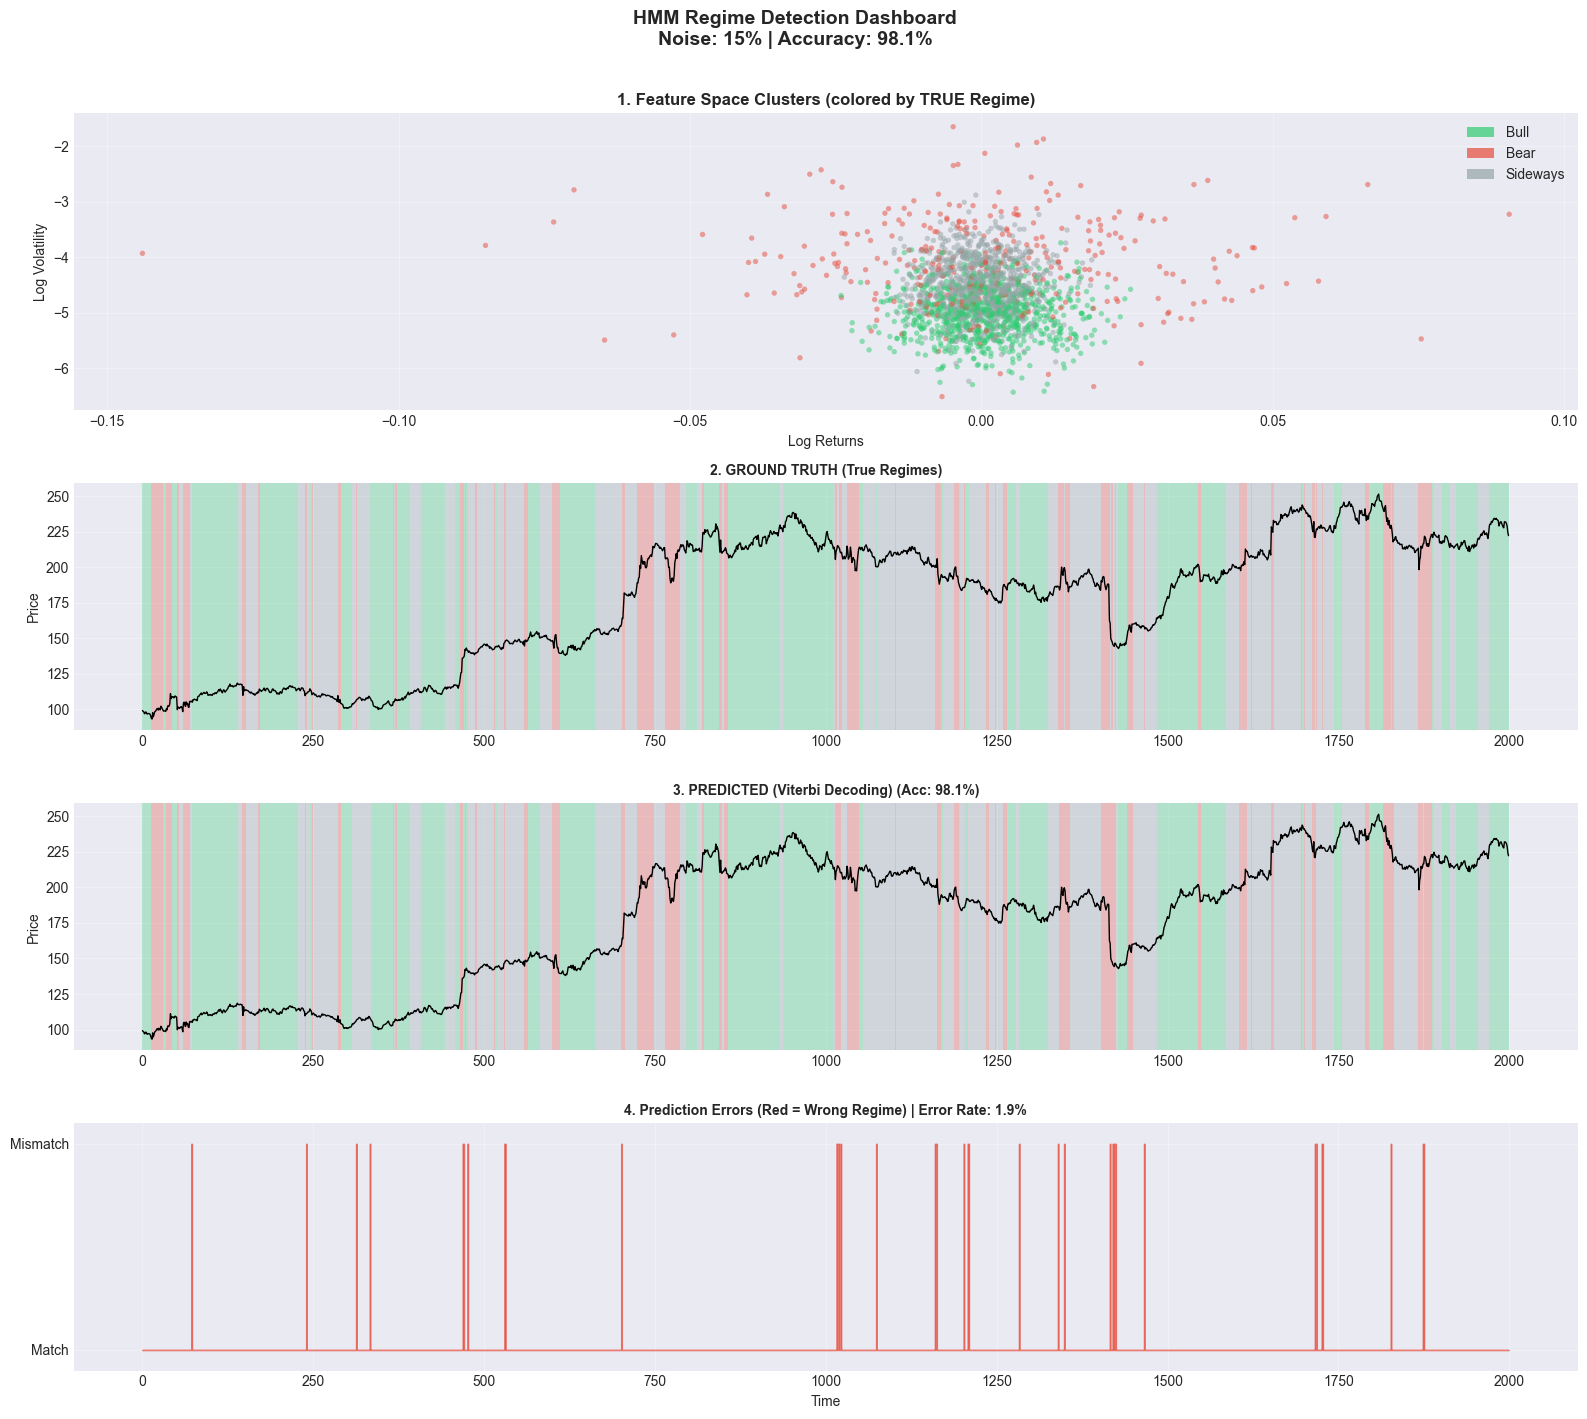

In [ ]:

# Helper function to plot regime backgrounds
def plot_regime_bg(ax, Z, data, title, acc=None, regime_names=None, regime_colors=None, ylabel="Value"):
    """Plot data series with colored regime backgrounds."""
    if regime_names is None:
        regime_names = REGIME_NAMES
    if regime_colors is None:
        regime_colors = REGIME_COLORS
    
    ax.plot(data, 'k', lw=1)
    
    # Find regime change points
    changes = np.concatenate(([0], np.where(Z[:-1] != Z[1:])[0] + 1, [len(Z)]))
    for i in range(len(changes)-1):
        s, e = changes[i], changes[i+1]
        regime_name = regime_names.get(Z[s], f"State {Z[s]}")
        color = regime_colors.get(regime_name, '#95a5a6')
        ax.axvspan(s, e, color=color, alpha=0.3, lw=0)
    
    title_text = title
    if acc is not None and DATA_TYPE != "Real":
        title_text += f" (Acc: {acc:.1%})"
    ax.set_title(title_text, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

# Use X_raw[:, 0] as the primary time series (Price proxy or Principal Component)
ts_data = X_raw[:, 0]
ts_label = feature_names[0] if 'feature_names' in globals() else "Feature 0"

# Create comprehensive dashboard
if DATA_TYPE == "Real":
    fig = plt.figure(figsize=(18, 10))
    # Layout: Top row for Clusters (Split into 2D views or 3D if possible), Bottom row for Time Series
    gs = fig.add_gridspec(2, 2)
    
    # --- PLOT 1: Feature Space Clusters (3D if > 2 features, else 2D) ---
    if X_raw.shape[1] >= 3:
        from mpl_toolkits.mplot3d import Axes3D
        ax_clust = fig.add_subplot(gs[0, 0], projection='3d')
        colors_pred = [REGIME_COLORS.get(REGIME_NAMES.get(z, f"State {z}"), '#95a5a6') for z in Z_pred_aligned]
        ax_clust.scatter(X_raw[:, 0], X_raw[:, 1], X_raw[:, 2], c=colors_pred, alpha=0.6, s=20, edgecolors='none')
        ax_clust.set_xlabel(feature_names[0])
        ax_clust.set_ylabel(feature_names[1])
        ax_clust.set_zlabel(feature_names[2])
        ax_clust.set_title("1. 3D Feature Clusters (Colored by Regime)", fontweight='bold')
    else:
        ax_clust = fig.add_subplot(gs[0, 0])
        colors_pred = [REGIME_COLORS.get(REGIME_NAMES.get(z, f"State {z}"), '#95a5a6') for z in Z_pred_aligned]
        ax_clust.scatter(X_raw[:, 0], X_raw[:, 1], c=colors_pred, alpha=0.6, s=20, edgecolors='none')
        ax_clust.set_title("1. Feature Space Clusters", fontweight='bold')
        ax_clust.set_xlabel(feature_names[0])
        ax_clust.set_ylabel(feature_names[1])
        ax_clust.grid(True, alpha=0.3)
    
    # --- PLOT 2: Regime Separation (Violin Plot for 1st feature) ---
    # Show distribution of first feature per regime
    ax_dist = fig.add_subplot(gs[0, 1])
    import seaborn as sns
    df_plot = pd.DataFrame({'Value': X_raw[:, 0], 'Regime': [REGIME_NAMES.get(z, str(z)) for z in Z_pred_aligned]})
    sns.violinplot(x='Regime', y='Value', data=df_plot, ax=ax_dist, palette=REGIME_COLORS)
    ax_dist.set_title(f"Distribution of {feature_names[0]} by Regime", fontweight='bold')
    
    # --- PLOT 3: Predicted Regimes over Time ---
    ax_pred = fig.add_subplot(gs[1, :])
    plot_regime_bg(ax_pred, Z_pred_aligned, ts_data, f"Time Series Regime Overlay ({ts_label})", 
                   ylabel=ts_label)
    
    plt.suptitle(f"HMM Regime Detection (Real Data) | Log-Likelihood: {logprob:.0f}", 
                 fontsize=14, fontweight='bold', y=1.01)

else:
    # Full Dashboard for Synthetic Data
    fig = plt.figure(figsize=(16, 14))
    gs = fig.add_gridspec(4, 2, height_ratios=[1.2, 1, 1, 1])

    # --- PLOT 1: Feature Space Clusters (Top Row, Full Width) ---
    ax_clust = fig.add_subplot(gs[0, :])
    colors_true = [REGIME_COLORS[REGIME_NAMES[z]] for z in Z_true]
    ax_clust.scatter(X_raw[:, 0], X_raw[:, 1], c=colors_true, alpha=0.5, s=15, edgecolors='none')

    # Add legend
    legend_elements = [Patch(facecolor=REGIME_COLORS[name], label=name, alpha=0.7) 
                       for name in ["Bull", "Bear", "Sideways"]]
    ax_clust.legend(handles=legend_elements, loc='upper right')
    ax_clust.set_title("1. Feature Space Clusters (colored by TRUE Regime)", fontweight='bold', fontsize=12)
    ax_clust.set_xlabel("Log Returns")
    ax_clust.set_ylabel("Log Volatility")
    ax_clust.grid(True, alpha=0.3)

    # --- PLOT 2: Ground Truth ---
    ax_true = fig.add_subplot(gs[1, :])
    plot_regime_bg(ax_true, Z_true, ts_data, "2. GROUND TRUTH (True Regimes)", ylabel="Value")

    # --- PLOT 3: Predicted (Viterbi, aligned) ---
    ax_pred = fig.add_subplot(gs[2, :], sharex=ax_true)
    plot_regime_bg(ax_pred, Z_pred_aligned, ts_data, "3. PREDICTED (Viterbi Decoding)", acc=accuracy, ylabel="Value")

    # --- PLOT 4: Prediction Errors ---
    ax_err = fig.add_subplot(gs[3, :], sharex=ax_true)
    # Ensure equal length if needed (though they should vary only by slight shift if any)
    errors = (Z_true != Z_pred_aligned).astype(int)
    ax_err.fill_between(range(len(errors)), errors, color='#e74c3c', alpha=0.7, step='mid')
    ax_err.set_ylim(-0.1, 1.1)
    ax_err.set_yticks([0, 1])
    ax_err.set_yticklabels(["Match", "Mismatch"])
    ax_err.set_title(f"4. Prediction Errors (Red = Wrong Regime) | Error Rate: {errors.mean():.1%}", 
                     fontweight='bold', fontsize=10)
    ax_err.set_xlabel("Time")
    ax_err.grid(True, alpha=0.3)

    plt.suptitle(f"HMM Regime Detection Dashboard\nNoise: {NOISE_LEVEL:.0%} | Accuracy: {accuracy:.1%}", 
                 fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()


### 5.2 Online vs Offline Filtering

Compare Viterbi (offline, smoothed) vs Online Filter (real-time, lagged):

Running Online Filter (Forward Algorithm)...
Online Filter Accuracy: 96.8%
Viterbi (Offline) Accuracy: 98.1%


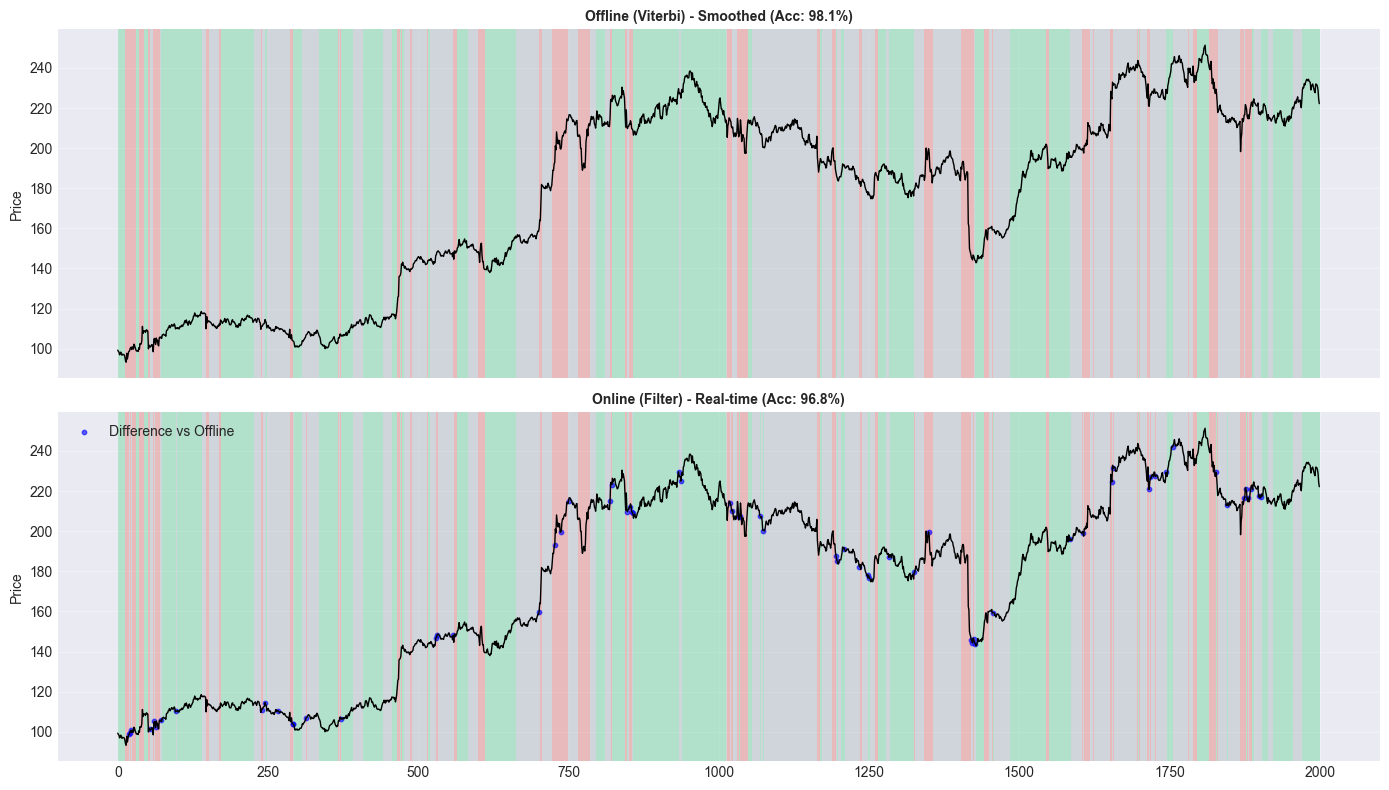

In [ ]:
def get_online_states(model, X):
    """
    Computes the most likely state at each time t given observations up to t.
    This simulates a real-time filter (no look-ahead).
    """
    framelogprob = model._compute_log_likelihood(X)
    log_transmat = np.log(model.transmat_)
    n_samples, n_components = len(X), model.n_components
    log_alpha = np.zeros((n_samples, n_components))
    
    # Initialization
    log_alpha[0] = np.log(model.startprob_) + framelogprob[0]
    
    # Forward pass
    for t in range(1, n_samples):
        for j in range(n_components):
            # log(sum(exp(log_alpha[t-1] + log_transmat[:, j])))
            log_alpha[t, j] = np.logaddexp.reduce(log_alpha[t-1] + log_transmat[:, j]) + framelogprob[t, j]
    
    # At each step t, pick the state with max probability given data 0...t
    return np.argmax(log_alpha, axis=1)

# Run Online Filter
print("Running Online Filter (Forward Algorithm)...")
Z_online_raw = get_online_states(model, X_scaled)

# Align labels using the SAME mapping derived from Viterbi/Hungarian
# (We assume the model states mean the same thing)
Z_online_aligned = np.array([mapping[z] for z in Z_online_raw])

# Calculate metrics
if DATA_TYPE != "Real":
    acc_online = accuracy_score(Z_true, Z_online_aligned)
    print(f"Online Filter Accuracy: {acc_online:.1%}")
    print(f"Viterbi (Offline) Accuracy: {accuracy:.1%}")
else:
    acc_online = None
    print("Online Filter run complete (No Ground Truth for accuracy)")

# Plot Comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Viterbi
plot_regime_bg(axes[0], Z_pred_aligned, price, "Offline (Viterbi) - Smoothed", acc=accuracy if DATA_TYPE != "Real" else None)

# Online
plot_regime_bg(axes[1], Z_online_aligned, price, "Online (Filter) - Real-time", acc=acc_online)

# Highlight differences
diffs = np.where(Z_pred_aligned != Z_online_aligned)[0]
axes[1].scatter(diffs, price[diffs], c='blue', s=10, label='Difference vs Offline', alpha=0.6)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 6. Model Selection (AIC/BIC)

Calculate Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) to evaluate model fit vs complexity.

Comparing models with k=1..7 regimes...
k=1: AIC=21901.9, BIC=21980.3, LogL=-10937.0
k=2: AIC=19372.6, BIC=19546.2, LogL=-9655.3
k=2: AIC=19372.6, BIC=19546.2, LogL=-9655.3
k=3: AIC=17347.5, BIC=17627.6, LogL=-8623.8
k=3: AIC=17347.5, BIC=17627.6, LogL=-8623.8
k=4: AIC=17334.7, BIC=17732.4, LogL=-8596.4
k=4: AIC=17334.7, BIC=17732.4, LogL=-8596.4
k=5: AIC=17382.9, BIC=17909.4, LogL=-8597.4
k=5: AIC=17382.9, BIC=17909.4, LogL=-8597.4
k=6: AIC=17383.5, BIC=18050.0, LogL=-8572.7
k=6: AIC=17383.5, BIC=18050.0, LogL=-8572.7
k=7: AIC=17401.3, BIC=18219.0, LogL=-8554.6
k=7: AIC=17401.3, BIC=18219.0, LogL=-8554.6


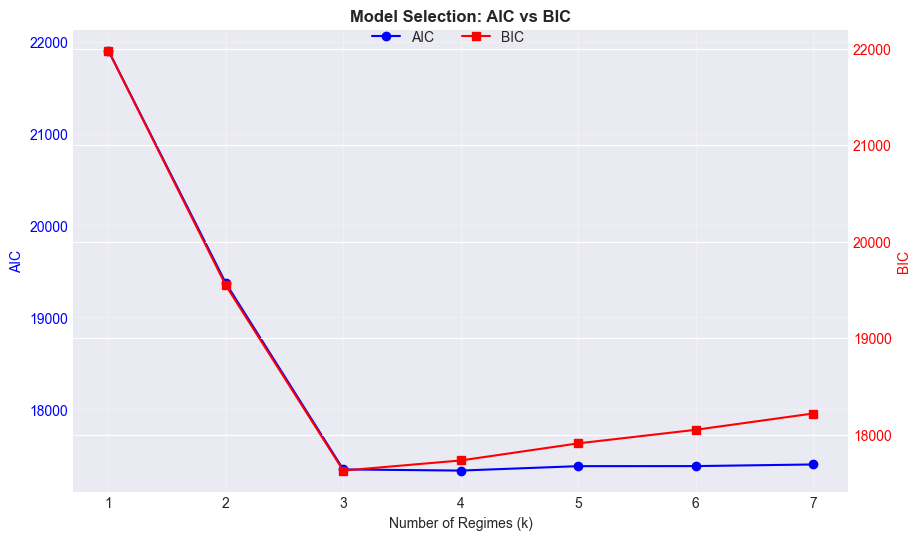


Optimal k by AIC: 4
Optimal k by BIC: 3


In [38]:

def calculate_information_criteria(model, X):
    """
    Calculate AIC and BIC for the HMM.
    AIC = 2k - 2ln(L)
    BIC = k*ln(n) - 2ln(L)
    """
    try:
        log_likelihood = model.score(X)
    except:
        return np.inf, np.inf, 0, -np.inf
        
    n_samples = len(X)
    
    # Calculate number of parameters
    n_features = model.n_features
    n_components = model.n_components
    
    # 1. Start probabilities: n_components - 1
    n_startprob = n_components - 1
    
    # 2. Transition matrix: n_components * (n_components - 1)
    n_transmat = n_components * (n_components - 1)
    
    # 3. Means: n_components * n_features
    n_means = n_components * n_features
    
    # 4. Covariances (full): n_components * n_features * (n_features + 1) / 2
    n_covars = n_components * n_features * (n_features + 1) / 2
    
    k = n_startprob + n_transmat + n_means + n_covars
    
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n_samples) - 2 * log_likelihood
    
    return aic, bic, k, log_likelihood

# Compare models with different number of regimes
print("Comparing models with k=2..10 regimes (using 10 initializations per k)...")
results = []
k_values = range(2, 11)

for k in k_values:
    # Fit model with multiple initializations to avoid local optima
    try:
        # Increasing n_init and n_iter for stability
        model_k = hmm.GaussianHMM(n_components=k, covariance_type="full", n_iter=200, n_init=10, random_state=42)
        model_k.fit(X_scaled)
        
        # Calculate metrics
        aic, bic, n_params, ll = calculate_information_criteria(model_k, X_scaled)
        results.append({
            'k': k,
            'AIC': aic,
            'BIC': bic,
            'LogLikelihood': ll,
            'Params': n_params
        })
        print(f"k={k:2d}: AIC={aic:10.1f}, BIC={bic:10.1f}, LogL={ll:10.1f}")
    except Exception as e:
        print(f"k={k}: Failed to fit ({str(e)})")

# Convert to DataFrame for easier plotting
import pandas as pd
df_results = pd.DataFrame(results)

# Plot AIC and BIC
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(df_results['k'], df_results['AIC'], 'b-o', label='AIC')
ax1.set_xlabel('Number of Regimes (k)')
ax1.set_ylabel('AIC', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_results['k'], df_results['BIC'], 'r-s', label='BIC')
ax2.set_ylabel('BIC', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Model Selection: AIC vs BIC', fontweight='bold')
# Align legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=2)
plt.tight_layout()
plt.show()

# Find optimal k
if not df_results.empty:
    best_aic_k = df_results.loc[df_results['AIC'].idxmin(), 'k']
    best_bic_k = df_results.loc[df_results['BIC'].idxmin(), 'k']

    print(f"\nOptimal k by AIC: {best_aic_k}")
    print(f"Optimal k by BIC: {best_bic_k}")
